In [1]:
import pandas as pd

In [ ]:
# df_excel = pd.read_excel('../data/02_silver/consolidado_impacto_modelo.xlsx', sheet_name='painel')
# df_excel.to_csv('../data/02_silver/consolidado_impacto_modelo.csv', index=False)
df = pd.read_csv('../data/02_silver/consolidado_impacto_modelo.csv')

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [25]:
df = pd.read_csv('../data/02_silver/consolidado_impacto_modelo.csv')

In [26]:

# Visão geral / qualidade — shape, contagens de tratamento×controle, fases (pré/durante/pós), 
# qualidade do pareamento e % de nulos (atenção: tier_projetado_max, mw_construido_total e 
# whitespace_construido_sqm_total têm 65–79% de nulos).

# ---------------------------------------------------------------
# 1. VISÃO GERAL E QUALIDADE DOS DADOS
# ---------------------------------------------------------------
print("=" * 70)
print("1. VISÃO GERAL")
print("=" * 70)
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
print(f"Data centers/áreas únicas (site_id): {df['site_id'].nunique()}")
print(f"Pares (pareado_com): {df['pareado_com'].nunique()}")
print("\nDistribuição tipo (tratamento x controle):")
print(df["tipo"].value_counts())
print("\nDistribuição fase da obra:")
print(df["fase"].value_counts())
print("\nQualidade do pareamento:")
print(df["qualidade_par"].value_counts())

print("\n% de valores nulos por coluna (top 15):")
nulls = (df.isna().mean() * 100).sort_values(ascending=False).head(15)
print(nulls.round(1))

1. VISÃO GERAL
Linhas: 204 | Colunas: 51
Data centers/áreas únicas (site_id): 30
Pares (pareado_com): 15

Distribuição tipo (tratamento x controle):
tipo
controle      102
tratamento    102
Name: count, dtype: int64

Distribuição fase da obra:
fase
pre        86
durante    70
pos        48
Name: count, dtype: int64

Qualidade do pareamento:
qualidade_par
ruim         132
bom           44
aceitavel     28
Name: count, dtype: int64

% de valores nulos por coluna (top 15):
tier_projetado_max                78.9000
mw_construido_total               65.7000
whitespace_construido_sqm_total   65.7000
n_predios_datacentermap           65.7000
tier                              50.0000
bioma                             50.0000
regiao                            50.0000
ids_datacenter                    45.1000
populacao                         16.7000
populacao_tipo_estimativa         16.7000
pib_mil_reais                      7.8000
pessoal_ocupado_total              2.9000
emprego_formal_total 

In [27]:
# ---------------------------------------------------------------
# 2. VARIÁVEIS-ALVO A ACOMPANHAR
# ---------------------------------------------------------------
VARS_SATELITE = [
    "prop_vegetacao_densa", "prop_vegetacao_rala",
    "prop_solo_exposto_obras", "prop_construida_urbana", "prop_agua",
]
VARS_CLIMA = ["lst_media_celsius"]
VARS_SOCIO = ["populacao", "emprego_formal_total", "pib_mil_reais", "numero_empresas"]
VARS_ALVO = VARS_SATELITE + VARS_CLIMA + VARS_SOCIO

In [31]:
# ---------------------------------------------------------------
# 3. ESTATÍSTICAS DESCRITIVAS: TRATAMENTO x CONTROLE
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("2. MÉDIAS POR TIPO (TRATAMENTO x CONTROLE)")
print("=" * 70)
resumo_tipo = df.groupby("tipo")[VARS_ALVO].mean(numeric_only=True)
print(resumo_tipo.round(3).T)


2. MÉDIAS POR TIPO (TRATAMENTO x CONTROLE)
tipo                         controle    tratamento
prop_vegetacao_densa           0.2530        0.1460
prop_vegetacao_rala            0.3850        0.2710
prop_solo_exposto_obras        0.0210        0.0320
prop_construida_urbana         0.2720        0.4800
prop_agua                      0.0690        0.0690
lst_media_celsius             28.7770       30.2480
populacao                 879243.1410   727381.5760
emprego_formal_total      262088.0100   248359.6160
pib_mil_reais           39626584.9570 40395870.4570
numero_empresas            35956.8480    28850.9800


In [ ]:
# ---------------------------------------------------------------
# 4. CÁLCULO DE DELTAS EM RELAÇÃO AO ANO-BASE (BASELINE)
#    baseline = observação com o horizonte pré-obra mais próximo de 0
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("3. CÁLCULO DE DELTAS (variação vs. ano-base pré-obra)")
print("=" * 70)

df = df.sort_values(["site_id", "ano_relativo_ao_inicio_obra"])

# CORRIGIDO: estritamente antes da obra (horizonte 0 já é fase "durante",
# não "pre" - usar <= 0 fazia o ano-base cair em cima do próprio horizonte 0
# em todos os pares, zerando o efeito líquido ali por construção).
pre = df[df["ano_relativo_ao_inicio_obra"] < 0]
idx_baseline = pre.groupby("site_id")["ano_relativo_ao_inicio_obra"].idxmax()

# sites sem nenhuma linha pré-obra: usa o primeiro horizonte disponível como fallback
sites_sem_pre = set(df["site_id"]) - set(pre["site_id"])
if sites_sem_pre:
    idx_fallback = (
        df[df["site_id"].isin(sites_sem_pre)]
        .groupby("site_id")["ano_relativo_ao_inicio_obra"]
        .idxmin()
    )
    idx_baseline = pd.concat([idx_baseline, idx_fallback])

baseline_map = df.loc[idx_baseline].set_index("site_id")[VARS_ALVO]

for col in VARS_ALVO:
    df[f"delta_{col}"] = df.apply(
        lambda row: row[col] - baseline_map.loc[row["site_id"], col]
        if row["site_id"] in baseline_map.index else np.nan,
        axis=1,
    )

delta_cols = [f"delta_{c}" for c in VARS_ALVO]
print("Exemplo de deltas calculados:")
df[["site_id", "tipo", "ano_relativo_ao_inicio_obra"] + delta_cols[:3]].head(10).round(3)


In [35]:
df[df['pareado_com'] == 'angonap-fortaleza']

,site_id,tipo,pareado_com,ids_datacenter,n_predios_no_campus,municipio,uf,codigo_ibge,lat,lon,...,delta_prop_vegetacao_densa,delta_prop_vegetacao_rala,delta_prop_solo_exposto_obras,delta_prop_construida_urbana,delta_prop_agua,delta_lst_media_celsius,delta_populacao,delta_emprego_formal_total,delta_pib_mil_reais,delta_numero_empresas
7,angonap-fortaleza,tratamento,angonap-fortaleza,NaN,0,Fortaleza,CE,2304400,-3.7347,-38.4626,...,0.0019,-0.0047,0.0030,-0.0009,0.0007,0.2507,NaN,67322.0000,-5475703.0000,2476.0000
8,angonap-fortaleza,tratamento,angonap-fortaleza,NaN,0,Fortaleza,CE,2304400,-3.7347,-38.4626,...,-0.0030,0.0003,-0.0007,-0.0015,0.0050,-0.0884,NaN,38337.0000,-4381147.0000,2167.0000
9,angonap-fortaleza,tratamento,angonap-fortaleza,NaN,0,Fortaleza,CE,2304400,-3.7347,-38.4626,...,-0.0032,-0.0024,0.0000,0.0059,-0.0003,0.5455,-17766.0000,7047.0000,-1504346.0000,723.0000
10,angonap-fortaleza,tratamento,angonap-fortaleza,NaN,0,Fortaleza,CE,2304400,-3.7347,-38.4626,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
11,angonap-fortaleza,tratamento,angonap-fortaleza,NaN,0,Fortaleza,CE,2304400,-3.7347,-38.4626,...,0.0013,-0.0041,-0.0012,0.0051,-0.0010,0.2842,15765.0000,8948.0000,4788955.0000,-1401.0000
12,angonap-fortaleza,tratamento,angonap-fortaleza,NaN,0,Fortaleza,CE,2304400,-3.7347,-38.4626,...,0.0074,0.0016,-0.0054,-0.0025,-0.0010,0.5508,41860.0000,5691.0000,5809083.0000,2295.0000
13,angonap-fortaleza,tratamento,angonap-fortaleza,NaN,0,Fortaleza,CE,2304400,-3.7347,-38.4626,...,0.0075,0.0028,-0.0032,-0.0039,-0.0032,-0.1082,59130.0000,-28206.0000,3229235.0000,4209.0000
0,ctrl-angonap-fortaleza-p01,controle,angonap-fortaleza,NaN,0,Caucaia,CE,2303709,-3.6973,-38.6018,...,0.0153,-0.0074,0.0029,-0.0094,-0.0014,0.7218,NaN,5923.0000,-280025.0000,-303.0000
1,ctrl-angonap-fortaleza-p01,controle,angonap-fortaleza,NaN,0,Caucaia,CE,2303709,-3.6973,-38.6018,...,-0.0035,0.0047,0.0026,-0.0010,-0.0028,0.3157,NaN,6678.0000,-119508.0000,-127.0000
2,ctrl-angonap-fortaleza-p01,controle,angonap-fortaleza,NaN,0,Caucaia,CE,2303709,-3.6973,-38.6018,...,-0.0120,0.0095,0.0008,0.0032,-0.0015,0.8933,-4059.0000,-3148.0000,-418720.0000,135.0000


In [37]:
# ---------------------------------------------------------------
# 5. EVENT STUDY — variação média por horizonte, tratamento x controle
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("4. EVENT STUDY (variação média por horizonte)")
print("=" * 70)

event_study = (
    df.groupby(["ano_relativo_ao_inicio_obra", "tipo"])[delta_cols]
    .mean()
    .reset_index()
)
event_study.round(3)


4. EVENT STUDY (variação média por horizonte)


,ano_relativo_ao_inicio_obra,tipo,delta_prop_vegetacao_densa,delta_prop_vegetacao_rala,delta_prop_solo_exposto_obras,delta_prop_construida_urbana,delta_prop_agua,delta_lst_media_celsius,delta_populacao,delta_emprego_formal_total,delta_pib_mil_reais,delta_numero_empresas
0,-3,controle,-0.0150,0.0150,0.0030,-0.0040,0.0010,0.1000,48725.2500,-2794.7860,-4421333.8570,-12776.1430
1,-3,tratamento,-0.0070,0.0080,0.0060,-0.0060,-0.0010,0.3460,-9592.2500,-5159.0000,-7452250.2140,-9154.8570
2,-2,controle,-0.0130,0.0070,0.0010,0.0030,0.0010,0.0850,48598.7780,-14814.2140,-5402483.0710,-12088.8570
3,-2,tratamento,-0.0110,0.0110,0.0020,-0.0010,-0.0010,0.2210,-5585.7780,-5444.5710,-5695620.0000,-8271.5000
4,-1,controle,-0.0070,0.0060,0.0010,0.0000,0.0000,0.0450,42201.0830,-13836.4000,-2817866.8670,-10195.0000
5,-1,tratamento,-0.0060,0.0040,0.0020,0.0000,-0.0000,0.1850,-3227.1670,-5558.4670,-3587569.3330,-1628.7330
6,0,controle,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,0,tratamento,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,1,controle,-0.0150,0.0080,-0.0020,0.0080,0.0020,-0.1250,-7585.8180,11075.5330,3980644.5380,4755.6670
9,1,tratamento,-0.0090,-0.0020,0.0010,0.0070,0.0040,0.0260,-5061.5450,10768.5330,3555677.9230,4599.4000


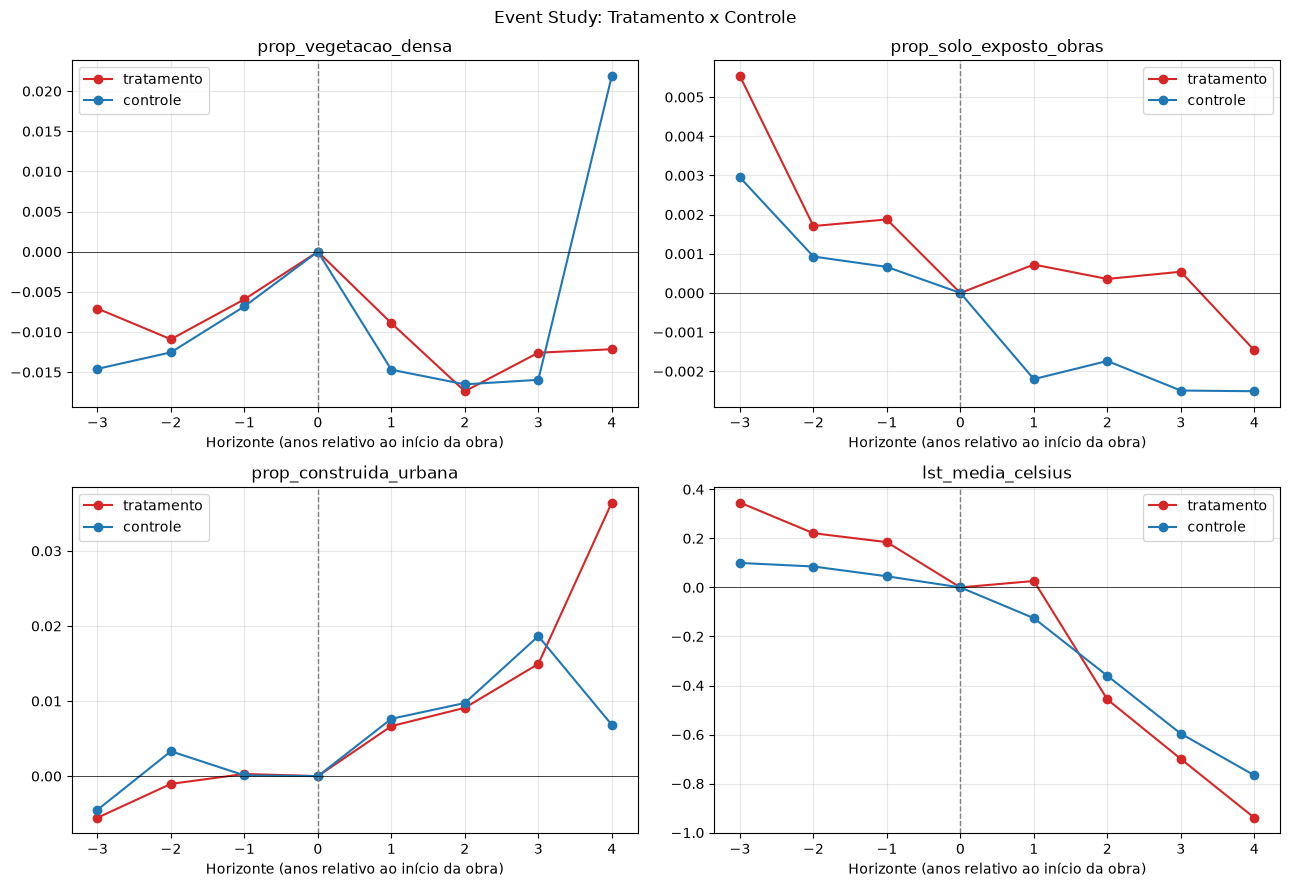

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_vars = ["delta_prop_vegetacao_densa", "delta_prop_solo_exposto_obras",
             "delta_prop_construida_urbana", "delta_lst_media_celsius"]
for ax, var in zip(axes.flat, plot_vars):
    for tipo, cor in [("tratamento", "tab:red"), ("controle", "tab:blue")]:
        sub = event_study[event_study["tipo"] == tipo]
        ax.plot(sub["ano_relativo_ao_inicio_obra"], sub[var], marker="o", label=tipo, color=cor)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(var.replace("delta_", ""))
    ax.set_xlabel("Horizonte (anos relativo ao início da obra)")
    ax.legend()
fig.suptitle("Event Study: Tratamento x Controle")
fig.tight_layout()
plt.show()

In [38]:
# ---------------------------------------------------------------
# 6. TESTE DE PLACEBO (pré-tendências)
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("5. TESTE DE PLACEBO (horizontes negativos)")
print("=" * 70)
pre_periodo = df[df["ano_relativo_ao_inicio_obra"] < 0]
placebo = pre_periodo.groupby("tipo")[delta_cols].mean()
print(placebo.round(4).T)
print("\n-> valores próximos de 0 nos horizontes negativos = boa notícia")
print("   (área não estava mudando sozinha antes da obra)")


5. TESTE DE PLACEBO (horizontes negativos)
tipo                               controle    tratamento
delta_prop_vegetacao_densa          -0.0112       -0.0079
delta_prop_vegetacao_rala            0.0092        0.0076
delta_prop_solo_exposto_obras        0.0015        0.0030
delta_prop_construida_urbana        -0.0004       -0.0020
delta_prop_agua                      0.0009       -0.0007
delta_lst_media_celsius              0.0761        0.2490
delta_populacao                  45986.3448    -5715.0345
delta_emprego_formal_total      -10559.8140    -5391.3256
delta_pib_mil_reais           -4181428.8372 -5532179.6047
delta_numero_empresas           -11651.9767    -6241.8605

-> valores próximos de 0 nos horizontes negativos = boa notícia
   (área não estava mudando sozinha antes da obra)


In [40]:
# ---------------------------------------------------------------
# 7. DIFERENÇA-EM-DIFERENÇAS (DiD) SIMPLES POR FASE
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("6. DIFERENÇA-EM-DIFERENÇAS (DiD) — fase 'pos' vs 'pre'")
print("=" * 70)

def did(var):
    m = df.groupby(["tipo", "fase"])[var].mean()
    try:
        trat_pre, trat_pos = m["tratamento", "pre"], m["tratamento", "pos"]
        ctrl_pre, ctrl_pos = m["controle", "pre"], m["controle", "pos"]
        return (trat_pos - trat_pre) - (ctrl_pos - ctrl_pre)
    except KeyError:
        return np.nan

did_resultados = {var: did(var) for var in VARS_ALVO}
did_df = pd.Series(did_resultados, name="efeito_DiD").sort_values()
print(did_df.round(4))


6. DIFERENÇA-EM-DIFERENÇAS (DiD) — fase 'pos' vs 'pre'
numero_empresas              -5199.8427
emprego_formal_total         -3636.0354
lst_media_celsius               -0.5738
prop_construida_urbana          -0.0097
prop_agua                       -0.0055
prop_solo_exposto_obras         -0.0044
prop_vegetacao_rala              0.0065
prop_vegetacao_densa             0.0132
populacao                    25734.0236
pib_mil_reais             15401022.5937
Name: efeito_DiD, dtype: float64


In [41]:
# ---------------------------------------------------------------
# 8. IMPACTO POR QUALIDADE DO PAREAMENTO
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("7. Nº de observações por qualidade de pareamento x tipo")
print("=" * 70)
print(pd.crosstab(df["qualidade_par"], df["tipo"]))


7. Nº de observações por qualidade de pareamento x tipo
tipo           controle  tratamento
qualidade_par                      
aceitavel            14          14
bom                  22          22
ruim                 66          66


In [22]:
# ---------------------------------------------------------------
# 9. RANKING: DATA CENTERS COM MAIOR PERDA DE VEGETAÇÃO / AUMENTO DE LST
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("8. RANKING — maior perda de vegetação densa (tratamento, fase pós)")
print("=" * 70)
pos_trat = df[(df["tipo"] == "tratamento") & (df["fase"] == "pos")]
ranking_veg = pos_trat.groupby("municipio")["delta_prop_vegetacao_densa"].mean().sort_values()
print(ranking_veg.round(3).head(10))

print("\n" + "=" * 70)
print("9. RANKING — maior aumento de LST (tratamento, fase pós)")
print("=" * 70)
ranking_lst = pos_trat.groupby("municipio")["delta_lst_media_celsius"].mean().sort_values(ascending=False)
print(ranking_lst.round(3).head(10))


8. RANKING — maior perda de vegetação densa (tratamento, fase pós)
municipio
Maracanaú             -0.067
Vinhedo               -0.054
Jundiaí               -0.048
Paulínia              -0.045
Porto Alegre          -0.038
João Pessoa           -0.019
São João de Meriti    -0.006
Goiânia               -0.001
Santana de Parnaíba    0.006
Sumaré                 0.007
Name: delta_prop_vegetacao_densa, dtype: float64

9. RANKING — maior aumento de LST (tratamento, fase pós)
municipio
Sumaré                 1.080
João Pessoa            0.973
Jundiaí               -0.025
Paulínia              -0.063
Fortaleza             -0.108
Maracanaú             -0.523
Vinhedo               -0.673
Santana de Parnaíba   -0.936
Barueri               -0.997
Porto Alegre          -1.078
Name: delta_lst_media_celsius, dtype: float64


In [23]:
# ---------------------------------------------------------------
# 10. CORRELAÇÃO ENTRE VARIÁVEIS
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("10. Matriz de correlação (satélite, LST, socioeconômico)")
print("=" * 70)
corr = df[VARS_ALVO + ["mw_construido_total", "n_predios_no_campus"]].corr(numeric_only=True)
print(corr.round(2))


10. Matriz de correlação (satélite, LST, socioeconômico)
                         prop_vegetacao_densa  prop_vegetacao_rala  \
prop_vegetacao_densa                     1.00                -0.06   
prop_vegetacao_rala                     -0.06                 1.00   
prop_solo_exposto_obras                 -0.13                -0.39   
prop_construida_urbana                  -0.60                -0.42   
prop_agua                               -0.17                -0.42   
lst_media_celsius                       -0.62                -0.01   
populacao                               -0.18                -0.15   
emprego_formal_total                    -0.18                -0.15   
pib_mil_reais                           -0.11                -0.11   
numero_empresas                         -0.16                -0.09   
mw_construido_total                     -0.22                 0.63   
n_predios_no_campus                     -0.20                 0.08   

                         prop_s

In [ ]:
# ---------------------------------------------------------------
# 11. EFEITO LÍQUIDO POR PAR E HORIZONTE
#     efeito_liquido = delta_tratamento - delta_controle
#     (compara cada tratamento só com o seu próprio contrafactual)
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("11. EFEITO LÍQUIDO POR PAR (delta_tratamento - delta_controle)")
print("=" * 70)

pares = df["pareado_com"].dropna().unique()

registros = []
for par in pares:
    grupo = df[df["pareado_com"] == par]
    trat = grupo[grupo["tipo"] == "tratamento"].set_index("ano_relativo_ao_inicio_obra")
    ctrl = grupo[grupo["tipo"] == "controle"].set_index("ano_relativo_ao_inicio_obra")

    horizontes_comuns = trat.index.intersection(ctrl.index)
    for h in horizontes_comuns:
        for var in VARS_ALVO:
            dcol = f"delta_{var}"
            registros.append({
                "par": par,
                "horizonte": h,
                "variavel": var,
                "efeito_liquido": trat.loc[h, dcol] - ctrl.loc[h, dcol],
            })

efeito_df = pd.DataFrame(registros)
print(f"{len(efeito_df)} registros (pares x horizontes x variáveis)")
efeito_df.head(10)

In [ ]:
# ---------------------------------------------------------------
# 12. CURVA ÚNICA — média/mediana do efeito líquido entre os pares, por horizonte
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("12. CURVA DE EFEITO LÍQUIDO (agregado entre os pares)")
print("=" * 70)

curva = (
    efeito_df
    .groupby(["variavel", "horizonte"])["efeito_liquido"]
    .agg(media="mean", mediana="median", desvio_padrao="std", n_pares="count")
    .reset_index()
    .sort_values(["variavel", "horizonte"])
)

print("Vegetação densa:")
print(curva[curva["variavel"] == "prop_vegetacao_densa"].to_string(index=False))
print("\nLST média:")
print(curva[curva["variavel"] == "lst_media_celsius"].to_string(index=False))

In [ ]:
# ---------------------------------------------------------------
# 13. TESTE DE PLACEBO SOBRE A CURVA (horizontes negativos ~ 0?)
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("13. TESTE DE PLACEBO (efeito líquido médio nos horizontes pré-obra)")
print("=" * 70)
placebo_curva = (
    curva[curva["horizonte"] < 0]
    .groupby("variavel")["media"]
    .mean()
    .sort_values(key=abs)
)
print(placebo_curva.round(4))
print("\n-> perto de 0 = boa notícia (tratamento e controle se moviam junto antes da obra)")

In [ ]:
# ---------------------------------------------------------------
# 14. GRÁFICO — curva de efeito líquido por horizonte, com faixa de erro padrão
#     obs.: só 1 par (ascenty-hortolandia) tem dado em horizonte +4 -
#     mantê-lo no gráfico junto com pontos de 14-15 pares distorce a curva
#     (n=1 aparece com o mesmo peso visual que uma média de 15). Por isso
#     o gráfico fica limitado a -3..+3, que é o intervalo comum aos 15 pares.
# ---------------------------------------------------------------
HORIZONTE_MIN, HORIZONTE_MAX = -3, 3

vars_para_plotar = ["prop_vegetacao_densa", "prop_solo_exposto_obras",
                     "prop_construida_urbana", "lst_media_celsius"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, var in zip(axes.flat, vars_para_plotar):
    sub = curva[
        (curva["variavel"] == var)
        & curva["horizonte"].between(HORIZONTE_MIN, HORIZONTE_MAX)
    ].sort_values("horizonte")
    erro_padrao = sub["desvio_padrao"] / np.sqrt(sub["n_pares"])

    ax.plot(sub["horizonte"], sub["media"], marker="o", color="tab:red", label="efeito líquido médio")
    ax.fill_between(
        sub["horizonte"],
        sub["media"] - erro_padrao,
        sub["media"] + erro_padrao,
        color="tab:red", alpha=0.2, label="± erro padrão",
    )
    # anota o n de pares por trás de cada ponto
    for _, row in sub.iterrows():
        ax.annotate(f"n={int(row['n_pares'])}", (row["horizonte"], row["media"]),
                    textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center", color="dimgray")

    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(var)
    ax.set_xlabel("Horizonte (anos relativo ao início da obra)")
    ax.legend(fontsize=8)

fig.suptitle("Efeito líquido médio entre os pares, por horizonte (DiD par-a-par)")
fig.tight_layout()
plt.show()